# Edge-Case 評估：G5 vs G7 False Positive 比較

用 `adversarial_tone.csv` 中的「平實改寫標題」（label=0）作為 edge-case 測資，
分別用 G5 與 G7 預測，比較 false positive rate。

**前置條件：**
- `dataset/processed/adversarial_tone.csv` 已產生
- `models/xlm-roberta-clickbait/` 為 G5 checkpoint
- `models/xlm-roberta-clickbait-g7/` 為 G7 checkpoint

## Step 1：建立 Edge-Case 測試集

In [1]:
import pandas as pd

edge = pd.read_csv("../dataset/processed/adversarial_tone.csv")
edge = edge[(edge["source"] == "adversarial_tone") & (edge["label"] == 0)]
print(f"edge-case 平實標題筆數：{len(edge)}")
print(edge["lang"].value_counts())

edge-case 平實標題筆數：800
lang
zh    400
en    400
Name: count, dtype: int64


## Step 2：G5 vs G7 False Positive Rate

注意：這些平實標題的原樣本可能出現在 G7 訓練集中（in-distribution），
分析結果在報告中需標註此限制。

In [2]:
import json
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

G5_DIR = "../models/xlm-roberta-clickbait"       # G5 模型
G7_DIR = "../models/xlm-roberta-clickbait-g7"    # G7 模型

def load_model(model_dir):
    tok = AutoTokenizer.from_pretrained(model_dir)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_dir).eval()
    return tok, mdl

def predict_one(tok, mdl, title, content):
    enc = tok(title, content, truncation=True, max_length=256, return_tensors="pt")
    with torch.no_grad():
        logits = mdl(**enc).logits
    return int(logits.argmax(dim=-1).item())

def fp_rate(model_dir, df):
    tok, mdl = load_model(model_dir)
    fp = sum(
        1 for _, r in df.iterrows()
        if predict_one(tok, mdl, r["title"], str(r.get("content", ""))) == 1
    )
    return fp / len(df)

print("Loading G5...")
g5_fp = fp_rate(G5_DIR, edge)
print(f"G5 false positive rate: {g5_fp:.4f}")

print("Loading G7...")
g7_fp = fp_rate(G7_DIR, edge)
print(f"G7 false positive rate: {g7_fp:.4f}")

result = {
    "edge_n": len(edge),
    "g5_false_positive_rate": g5_fp,
    "g7_false_positive_rate": g7_fp,
    "improvement": g5_fp - g7_fp,
}
print("\nResult:", result)

Path("../results").mkdir(exist_ok=True)
with open("../results/g5_vs_g7_edge_cases.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)
print("Saved to results/g5_vs_g7_edge_cases.json")

Loading G5...


c:\Users\tjx20\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


G5 false positive rate: 0.4050
Loading G7...
G7 false positive rate: 0.0037

Result: {'edge_n': 800, 'g5_false_positive_rate': 0.405, 'g7_false_positive_rate': 0.00375, 'improvement': 0.40125000000000005}
Saved to results/g5_vs_g7_edge_cases.json


## 驗證

- `g7_false_positive_rate` 應低於 `g5_false_positive_rate`
- 若沒下降，回頭檢查對抗資料品質或增加資料量
- 在 Report.md 標註：edge-case 測試集中平實標題的原 clickbait 版本可能出現在 G7 訓練集中，存在 in-distribution 偏差

## Step 3：視覺化 G5 vs G7 False Positive Rate

用柱狀圖直觀呈現 tone 對抗訓練在 edge-case 上的改善。

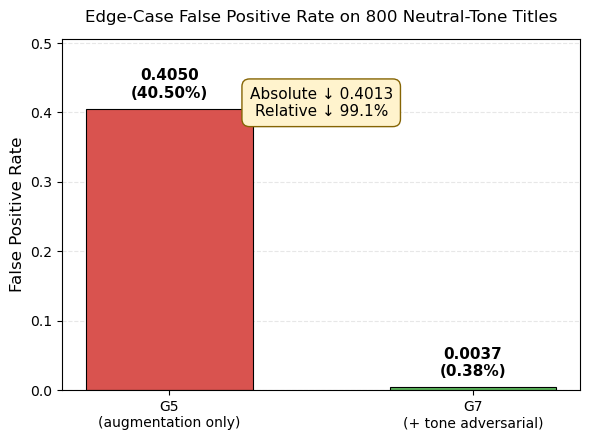

Figure saved to: ..\results\g5_vs_g7_edge_fp_rate.png


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

with open("../results/g5_vs_g7_edge_cases.json", "r", encoding="utf-8") as f:
    result = json.load(f)

models = ["G5\n(augmentation only)", "G7\n(+ tone adversarial)"]
fp_rates = [result["g5_false_positive_rate"], result["g7_false_positive_rate"]]
colors = ["#d9534f", "#5cb85c"]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(models, fp_rates, color=colors, width=0.55, edgecolor="black", linewidth=0.8)

for bar, rate in zip(bars, fp_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.012,
        f"{rate:.4f}\n({rate * 100:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylabel("False Positive Rate", fontsize=12)
ax.set_title(
    f"Edge-Case False Positive Rate on {result['edge_n']} Neutral-Tone Titles",
    fontsize=12,
    pad=12,
)
ax.set_ylim(0, max(fp_rates) * 1.25)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

improvement = result["improvement"]
rel_improvement = improvement / result["g5_false_positive_rate"] * 100
ax.annotate(
    f"Absolute ↓ {improvement:.4f}\nRelative ↓ {rel_improvement:.1f}%",
    xy=(0.5, 0.78),
    xycoords="axes fraction",
    ha="center",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff3cd", edgecolor="#856404"),
)

fig.tight_layout()
out_path = Path("../results/g5_vs_g7_edge_fp_rate.png")
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Figure saved to: {out_path}")

## Step 4：主 Test Set Macro F1 模型對比

把所有正式 stratified split 模型（G2/G4/G5/G6/G7）的主 test set Macro F1 畫成柱狀圖，
呈現整體實驗演進與 G7 在主 test 上的小幅退步。

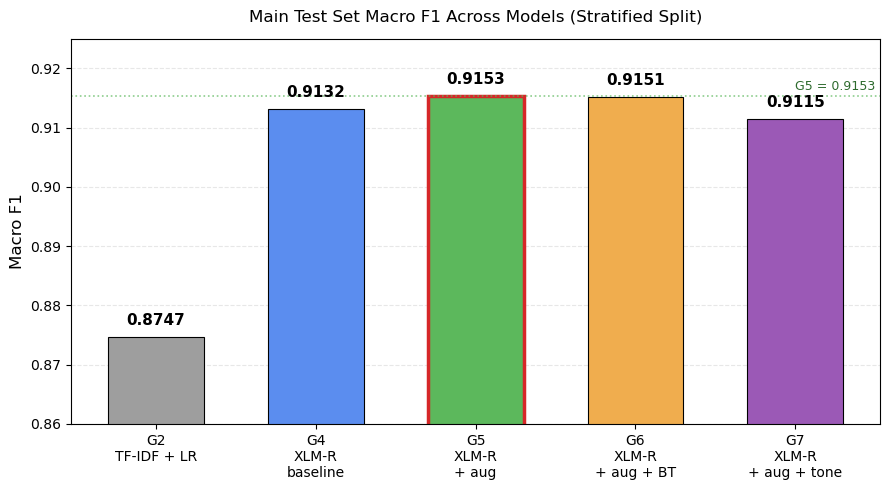

Figure saved to: ..\results\main_test_macro_f1_comparison.png


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

models = ["G2", "G4", "G5", "G6", "G7"]
descriptions = [
    "TF-IDF + LR",
    "XLM-R\nbaseline",
    "XLM-R\n+ aug",
    "XLM-R\n+ aug + BT",
    "XLM-R\n+ aug + tone",
]
macro_f1 = [0.8747, 0.9132, 0.9153, 0.9151, 0.9115]
colors = ["#9e9e9e", "#5b8def", "#5cb85c", "#f0ad4e", "#9b59b6"]

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(models))
bars = ax.bar(x, macro_f1, color=colors, width=0.6, edgecolor="black", linewidth=0.8)

for bar, score in zip(bars, macro_f1):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0015,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

best_idx = macro_f1.index(max(macro_f1))
bars[best_idx].set_edgecolor("#d62728")
bars[best_idx].set_linewidth(2.5)

ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n{d}" for m, d in zip(models, descriptions)], fontsize=10)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title(
    "Main Test Set Macro F1 Across Models (Stratified Split)",
    fontsize=12,
    pad=12,
)
ax.set_ylim(0.86, 0.925)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

ax.axhline(y=macro_f1[2], color="#5cb85c", linestyle=":", linewidth=1.2, alpha=0.7)
ax.text(
    len(models) - 0.5,
    macro_f1[2] + 0.0005,
    f"G5 = {macro_f1[2]:.4f}",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#2d6a2d",
)

fig.tight_layout()
out_path = Path("../results/main_test_macro_f1_comparison.png")
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Figure saved to: {out_path}")

## Step 5: Regression Test Set

Load manually-curated edge cases from `dataset/processed/regression_test.csv`,
run G7 predictions, and track which cases are still misclassified.

**Columns:** `error_type` (FP/FN/scale_mismatch), `note` (why this case is hard), `label` (ground truth)

**To add new samples:** edit `dataset/processed/regression_test.csv` and re-run these cells.

In [ ]:
import pandas as pd
from pathlib import Path

RT_PATH = "../dataset/processed/regression_test.csv"

rt = pd.read_csv(RT_PATH)
print(f"Regression test set: {len(rt)} samples")
if len(rt) == 0:
    print("No samples yet. Add edge cases to regression_test.csv.")
else:
    print(rt[["id", "lang", "title", "label", "error_type", "note"]].to_string(index=False))

In [ ]:
if len(rt) == 0:
    print("No samples, skipping prediction.")
else:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    G7_DIR = "../models/xlm-roberta-clickbait-g7"
    tok = AutoTokenizer.from_pretrained(G7_DIR)
    mdl = AutoModelForSequenceClassification.from_pretrained(G7_DIR).eval()

    def predict_g7(title, content):
        enc = tok(
            str(title), str(content),
            truncation=True, max_length=256, return_tensors="pt"
        )
        with torch.no_grad():
            logits = mdl(**enc).logits
        probs = torch.softmax(logits, dim=-1)[0]
        pred = int(logits.argmax(dim=-1).item())
        conf = float(probs[pred].item())
        return pred, round(conf, 4)

    preds, confs = [], []
    for _, row in rt.iterrows():
        p, c = predict_g7(row["title"], row.get("content", "") or "")
        preds.append(p)
        confs.append(c)

    rt = rt.copy()
    rt["g7_pred"] = preds
    rt["g7_conf"] = confs
    rt["correct"] = rt["g7_pred"] == rt["label"]

    total = len(rt)
    wrong = (~rt["correct"]).sum()
    print(f"Total: {total}, G7 wrong: {wrong} ({wrong/total*100:.1f}%)\n")

    wrong_df = rt[~rt["correct"]][["id","lang","title","label","g7_pred","g7_conf","error_type","note"]]
    if len(wrong_df):
        print("=== Still misclassified ===")
        print(wrong_df.to_string(index=False))
    else:
        print("All samples classified correctly by G7!")

In [ ]:
if len(rt) > 0 and "g7_pred" in rt.columns:
    summary = rt.groupby("error_type").agg(
        total=("correct", "count"),
        wrong=("correct", lambda x: (~x).sum()),
    ).assign(wrong_rate=lambda d: (d["wrong"] / d["total"]).round(3))
    print("=== Error type breakdown ===")
    print(summary.to_string())
else:
    print("No data to summarize.")